# Training a CNN on Handwritten Digits with PyTorch

In this notebook we build and train a **Convolutional Neural Network (CNN)** to classify handwritten digits (0–9) using PyTorch's `nn` module. This covers the core PyTorch workflow:

1. **Load and prepare the data** — convert to tensors, reshape, normalise.
2. **Define the model** — stack layers using `nn.Sequential`.
3. **Choose a loss function and optimizer** — cross-entropy loss + SGD.
4. **Train the model** — the training loop with forward pass, loss computation, backpropagation, and parameter update.
5. **Make predictions** — run the trained model on new examples.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn import datasets

X_digits, y_digits = load_digits(return_X_y=True)
X_digits.shape

(1797, 64)

---
## 1. Loading the Data

We use scikit-learn's `load_digits` dataset — a simplified version of MNIST with 8×8 grayscale images of handwritten digits (1,797 samples, 10 classes).

Each sample is a vector of 64 values (an 8×8 image flattened). Let's visualize one:

<Figure size 640x480 with 0 Axes>

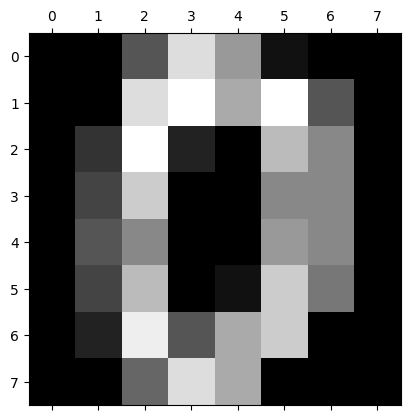

In [2]:
plt.gray()
plt.matshow(X_digits[0].reshape(8,8))
plt.show()

In [3]:
model = nn.Sequential(
    nn.Conv2d(1, 32, 5), nn.ReLU(),
    nn.Conv2d(32, 64, 3), nn.MaxPool2d(2), nn.ReLU(),
    nn.Flatten(),
    nn.Linear(64, 200), nn.ReLU(),
    nn.Linear(200, 10)
)

---
## 2. Defining the Model

We use `nn.Sequential` to stack layers into a pipeline. The architecture is a small CNN:

| Layer | Type | Output shape | Description |
|-------|------|-------------|-------------|
| Input | — | `(batch, 1, 8, 8)` | Grayscale image |
| `Conv2d(1, 32, 5)` | Convolution | `(batch, 32, 4, 4)` | 32 filters of size 5×5 |
| `ReLU` | Activation | `(batch, 32, 4, 4)` | Non-linearity |
| `Conv2d(32, 64, 3)` | Convolution | `(batch, 64, 2, 2)` | 64 filters of size 3×3 |
| `MaxPool2d(2)` | Pooling | `(batch, 64, 1, 1)` | Downsample by factor 2 |
| `ReLU` | Activation | `(batch, 64, 1, 1)` | Non-linearity |
| `Flatten` | Reshape | `(batch, 64)` | Flatten for the linear layer |
| `Linear(64, 200)` | Fully connected | `(batch, 200)` | Hidden layer |
| `ReLU` | Activation | `(batch, 200)` | Non-linearity |
| `Linear(200, 10)` | Fully connected | `(batch, 10)` | One output per digit class |

The output is a vector of 10 **logits** (raw scores) — the predicted class is the one with the highest score.

In [4]:
list(model.parameters())

[Parameter containing:
 tensor([[[[-0.1380, -0.0379,  0.0441, -0.1066, -0.0485],
           [ 0.1702,  0.0892,  0.0137,  0.0064,  0.1963],
           [-0.0934, -0.0657,  0.0397,  0.0756,  0.0145],
           [ 0.1575, -0.1768,  0.0537,  0.0062,  0.0167],
           [ 0.1138, -0.0587,  0.0801, -0.1997, -0.1969]]],
 
 
         [[[-0.1020, -0.0592,  0.0966, -0.1070,  0.0415],
           [-0.0347, -0.1901,  0.0084, -0.1446, -0.0854],
           [ 0.1928,  0.0833,  0.1325,  0.1465, -0.1594],
           [-0.0952,  0.1701, -0.1019, -0.0640, -0.1279],
           [ 0.0503,  0.0200,  0.1973,  0.1730,  0.1512]]],
 
 
         [[[ 0.0214, -0.1551,  0.0905, -0.1037, -0.1763],
           [-0.1104,  0.0861,  0.0002, -0.1359,  0.0931],
           [-0.1799, -0.0204, -0.0798,  0.1833, -0.0297],
           [-0.0926,  0.1555,  0.1195,  0.1988, -0.1558],
           [-0.1966,  0.0673,  0.1377,  0.0566,  0.0398]]],
 
 
         [[[ 0.0195,  0.0134, -0.1551,  0.0336,  0.1018],
           [ 0.1747,  0.0099,  

We can inspect all the learnable parameters (weights and biases) of the model. Each convolutional and linear layer has a weight tensor and a bias tensor:

`nn.Conv2d(in_channels, out_channels, kernel_size)`:
- **in_channels**: number of input channels (1 = grayscale, 3 = RGB).
- **out_channels**: number of filters (feature maps) the layer learns.
- **kernel_size**: size of the sliding window (5 means 5×5).

Each filter slides over the input and computes a dot product at each position, producing a **feature map**. Multiple filters detect different patterns (edges, curves, etc.).

---
## 3. Loss Function and Optimizer

Two ingredients are needed for training:
- A **loss function** that measures how far the model's predictions are from the true labels.
- An **optimizer** that updates the model's parameters to reduce the loss.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

`CrossEntropyLoss` combines a softmax and the negative log-likelihood in a single layer — it is the standard loss for multi-class classification. `SGD` is stochastic gradient descent with learning rate `lr=0.1`.

---
## 4. Preparing the Data

Before training, we need to:
1. **Convert** NumPy arrays to PyTorch tensors.
2. **Reshape** the flat 64-dimensional vectors into 8×8 images (with a channel dimension).
3. **Normalise** the pixel values to have zero mean and unit variance.
4. **Move** the data to GPU if available.

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Check whether a GPU is available. If so, we move the model and data to it for faster training:

In [7]:
model.to(device)
criterion.to(device)

CrossEntropyLoss()

In [8]:
X_tensor = torch.tensor(X_digits, dtype=torch.float32)
y_tensor = torch.tensor(y_digits, dtype=torch.long) 

X_tensor = X_tensor.view(-1, 1, 8, 8)
train_input, train_targets = X_tensor.to(device), y_tensor.to(device)

Convert the data to tensors and reshape. The CNN expects input of shape `(batch, channels, height, width)` — so we reshape from `(N, 64)` to `(N, 1, 8, 8)`:

In [9]:
train_input.shape

torch.Size([1797, 1, 8, 8])

In [10]:
mu, std = train_input.mean(), train_input.std()
train_input.sub_(mu).div_(std)

tensor([[[[-0.8118, -0.8118,  0.0193,  ..., -0.6456, -0.8118, -0.8118],
          [-0.8118, -0.8118,  1.3489,  ...,  1.6813,  0.0193, -0.8118],
          [-0.8118, -0.3131,  1.6813,  ...,  1.0165,  0.5179, -0.8118],
          ...,
          [-0.8118, -0.1469,  1.0165,  ...,  1.1827,  0.3517, -0.8118],
          [-0.8118, -0.4794,  1.5151,  ...,  1.1827, -0.8118, -0.8118],
          [-0.8118, -0.8118,  0.1855,  ..., -0.8118, -0.8118, -0.8118]]],


        [[[-0.8118, -0.8118, -0.8118,  ...,  0.0193, -0.8118, -0.8118],
          [-0.8118, -0.8118, -0.8118,  ...,  0.6841, -0.8118, -0.8118],
          [-0.8118, -0.8118, -0.3131,  ...,  0.1855, -0.8118, -0.8118],
          ...,
          [-0.8118, -0.8118, -0.6456,  ...,  0.1855, -0.8118, -0.8118],
          [-0.8118, -0.8118, -0.6456,  ...,  0.1855, -0.8118, -0.8118],
          [-0.8118, -0.8118, -0.8118,  ...,  0.8503, -0.8118, -0.8118]]],


        [[[-0.8118, -0.8118, -0.8118,  ...,  1.1827, -0.8118, -0.8118],
          [-0.8118, -0.811

**Normalise** the data to zero mean and unit variance. This helps the optimizer converge faster and prevents features with large values from dominating:

In [11]:
nb_epochs, batch_size = 10, 100

---
## 5. The Training Loop

Training a neural network in PyTorch follows this pattern for each mini-batch:

1. **Forward pass:** compute the model's output → `output = model(input)`
2. **Compute the loss:** compare output to the true labels → `loss = criterion(output, targets)`
3. **Zero the gradients:** clear gradients from the previous step → `optimizer.zero_grad()`
4. **Backward pass:** compute gradients of the loss w.r.t. all parameters → `loss.backward()`
5. **Update parameters:** take a gradient descent step → `optimizer.step()`

We repeat this for multiple **epochs** (full passes through the dataset). Within each epoch, the data is split into **mini-batches** for efficiency.

In [12]:
for epoch in range(nb_epochs):
    total_loss = 0
    for input, targets in zip(train_input.split(batch_size), train_targets.split(batch_size)):
        output = model(input)           # 1. Forward pass
        loss = criterion(output, targets) # 2. Compute loss
        optimizer.zero_grad()            # 3. Zero gradients
        loss.backward()                  # 4. Backward pass
        optimizer.step()                 # 5. Update parameters
        total_loss += loss.item()
    print(f"Epoch {epoch+1:2d}/{nb_epochs} — Loss: {total_loss:.4f}")

Epoch  1/10 — Loss: 40.0812
Epoch  2/10 — Loss: 33.6065
Epoch  3/10 — Loss: 18.2339
Epoch  4/10 — Loss: 11.7023
Epoch  5/10 — Loss: 7.5092
Epoch  6/10 — Loss: 5.4415
Epoch  7/10 — Loss: 4.0386
Epoch  8/10 — Loss: 3.1253
Epoch  9/10 — Loss: 2.4928
Epoch 10/10 — Loss: 2.0727


Let's compute the **training accuracy** — the percentage of training examples that the model classifies correctly. We use `torch.no_grad()` to disable gradient computation (faster and uses less memory):

In [13]:
with torch.no_grad():
    output = model(train_input)
    predictions = torch.argmax(output, dim=1)
    accuracy = (predictions == train_targets).float().mean()
    print(f"Training accuracy: {accuracy.item() * 100:.1f}%")

Training accuracy: 95.4%


In [14]:
x = torch.tensor([1,2,3,4])
x.unsqueeze(0)

tensor([[1, 2, 3, 4]])

---
## 6. Making Predictions

To predict the class of a single image, we pass it through the model and take the `argmax` of the output logits. We need to add a batch dimension with `.unsqueeze(0)` since the model expects input of shape `(batch, channels, H, W)`.

> **Recall:** `.unsqueeze(dim)` inserts a dimension of size 1 at position `dim`. So a tensor of shape `(1, 8, 8)` becomes `(1, 1, 8, 8)`.

In [15]:
example_input = X_tensor[0].unsqueeze(0)
with torch.no_grad():
    output = model(example_input)
print(f"output tensor:\n {output}\nthe prediction is:\n {torch.argmax(output).item()}")

output tensor:
 tensor([[ 8.7018, -5.4523, -0.5116, -1.0265, -2.3418,  2.1950, -1.7953, -3.4023,
         -2.1110,  1.6059]])
the prediction is:
 0


Let's visualize the model's predictions on a grid of examples:

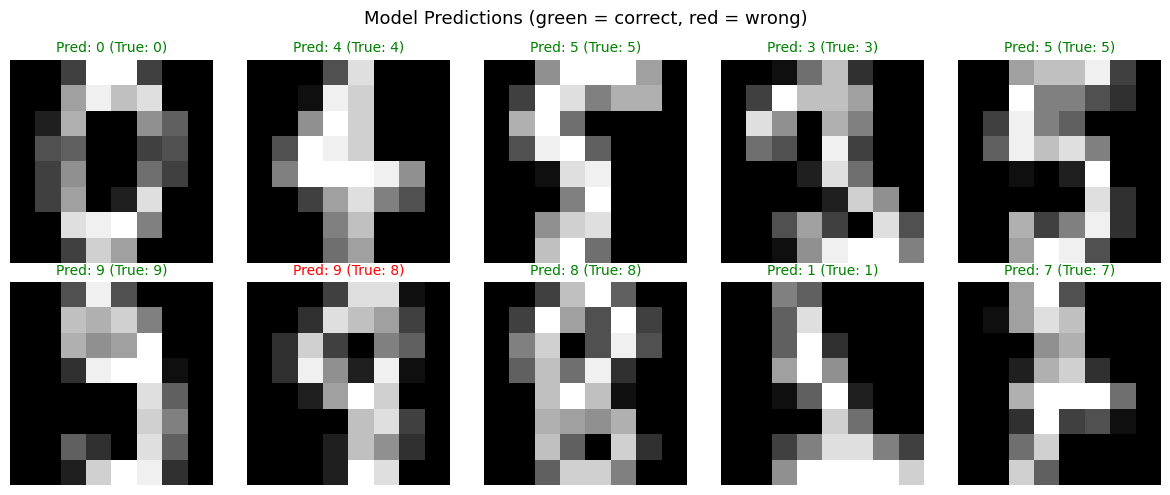

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
indices = torch.randint(0, len(X_tensor), (10,))

with torch.no_grad():
    for ax, idx in zip(axes.flat, indices):
        img = X_tensor[idx]
        output = model(img.unsqueeze(0))
        pred = torch.argmax(output).item()
        true = y_digits[idx]
        
        ax.imshow(img.squeeze().cpu().numpy(), cmap='gray')
        color = 'green' if pred == true else 'red'
        ax.set_title(f"Pred: {pred} (True: {true})", color=color, fontsize=10)
        ax.axis('off')

plt.suptitle("Model Predictions (green = correct, red = wrong)", fontsize=13)
plt.tight_layout()
plt.show()